# 🤖 Day 1 — Unsupervised Learning & K-Means

**BinX Tech — AI & Machine Learning Internship Program**
Week 5: Unsupervised Learning | Phase 2 → 3 — Clustering & Dimensionality Reduction

![status](https://img.shields.io/badge/status-complete-brightgreen)
![phase](https://img.shields.io/badge/phase-2%20%7C%20Core%20ML%20Training-blue)
![dataset](https://img.shields.io/badge/dataset-YourDatasetName-red)
![python](https://img.shields.io/badge/python-3.10%2B-orange)
![libraries](https://img.shields.io/badge/libraries-Scikit--learn%20%7C%20Pandas%20%7C%20Matplotlib-yellow)

## 🎯 Today's Mission
> Today we leave the world of labeled data (Supervised) and step into something new:
> data with **no answers given** 🕵️‍♂️ — our job is to discover the hidden structure ourselves!



<table>
  <tr>
    <th align="left">🎓 Objective</th>
    <th align="left">📌 Details</th>
  </tr>
  <tr>
    <td><b>1️⃣</b></td>
    <td>Understand the difference between <b>Supervised</b> & <b>Unsupervised</b> Learning</td>
  </tr>
  <tr>
    <td><b>2️⃣</b></td>
    <td>Run <code>K-Means</code> and interpret clusters & centroids</td>
  </tr>
  <tr>
    <td><b>3️⃣</b></td>
    <td>Choose the best <code>k</code> using two methods: Elbow ⚡ and Silhouette 🌟</td>
  </tr>
</table>

## 🧪 Hands-On Lab Checklist
- [x] 1️⃣ Load and scale the data (`StandardScaler`) 📏
- [x] 2️⃣ Run K-Means for k=1 to k=10 and plot Inertia 📉
- [x] 3️⃣ Compute Silhouette Score for the top candidate k values 🔍
- [x] 4️⃣ Visualize the final clusters beautifully 🎨
- [x] 5️⃣ Interpret each cluster in plain English 💬

☕️ Grab your coffee, fire up your machine — let's start the discovery! 🔥

---
## 📦 Step 0 — Imports & Setup
Every tool we need for today's adventure 🛠️

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 🎨 Make the plots look sharp from the start
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (9, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

%matplotlib inline

print('✅ All libraries loaded — let\'s go! 🚀')

✅ All libraries loaded — let's go! 🚀


---
## 📂 Step 1 — Load & Scale the Data

⚠️ **Golden rule:** K-Means relies on distance between points. If one feature has a huge range
(like income) and another is small (like age), the big one will dominate. The fix? `StandardScaler`, always! 📏✨

In [8]:
# 🔧 TODO: replace this with your real dataset path
# df = pd.read_csv('your_dataset.csv')

# 🎲 Demo dataset (delete once you load your real data)
from sklearn.datasets import make_blobs
X_demo, _ = make_blobs(n_samples=300, centers=4, n_features=2,
                        cluster_std=1.1, random_state=42)
df = pd.DataFrame(X_demo, columns=['feature_1', 'feature_2'])

print(f'📊 Data shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

📊 Data shape: 300 rows × 2 columns


,feature_1,feature_2
0,-9.343625,6.388694
1,-9.784782,6.900512
2,-1.604398,7.671358
3,-7.119077,-5.671455
4,-11.080265,6.214628


In [3]:
# 🔢 Keep numeric columns only
X = df.select_dtypes(include=[np.number])

# 📏 Scale the data — non-negotiable step!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('✅ Scaling done! First 5 rows after scaling:')
X_scaled[:5]

✅ Scaling done! First 5 rows after scaling:


array([[-1.12043043,  0.5693365 ],
       [-1.20365646,  0.65154497],
       [ 0.33960311,  0.77535876],
       [-0.70076123, -1.3677719 ],
       [-1.44805396,  0.54137789]])

---
## ⚡ Step 2 — The Elbow Method

We run K-Means for a range of k values and watch how **Inertia** drops.
We're looking for the point where the drop suddenly slows down — that's the 💎 **elbow** 💎.

⏳ Trying k values from 1 to 10...

   🔹 k= 1  →  Inertia = 600.00
   🔹 k= 2  →  Inertia = 317.07
   🔹 k= 3  →  Inertia = 74.60
   🔹 k= 4  →  Inertia = 20.87
   🔹 k= 5  →  Inertia = 18.67
   🔹 k= 6  →  Inertia = 16.62
   🔹 k= 7  →  Inertia = 14.69
   🔹 k= 8  →  Inertia = 12.95
   🔹 k= 9  →  Inertia = 11.64
   🔹 k=10  →  Inertia = 10.61

✅ Done! Plotting the elbow curve now 👇


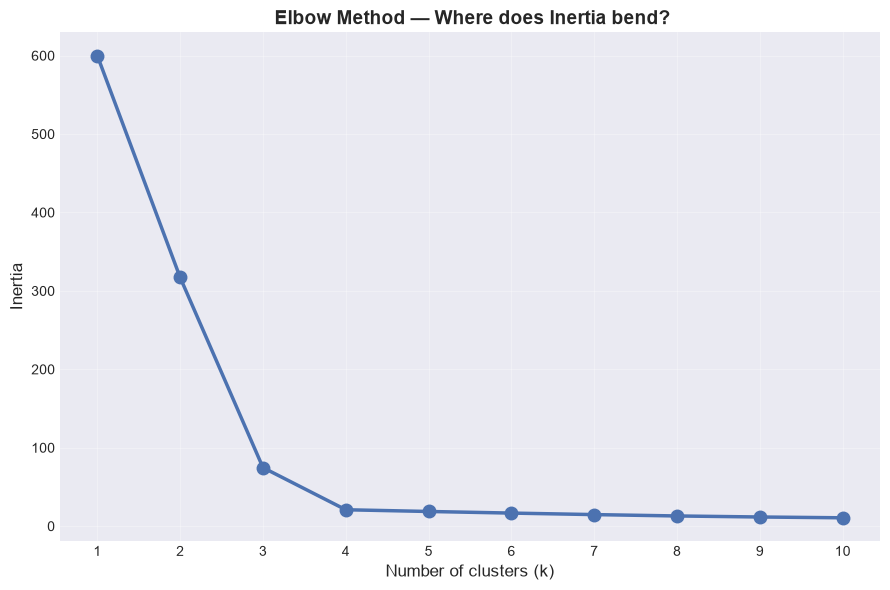

In [13]:
inertias = []
k_range = range(1, 11)

print('⏳ Trying k values from 1 to 10...\n')
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f'   🔹 k={k:2d}  →  Inertia = {km.inertia_:.2f}')

print('\n✅ Done! Plotting the elbow curve now 👇')

plt.figure(figsize=(9, 6))
plt.plot(list(k_range), inertias, marker='o', linewidth=2.5,
         markersize=9, color='#4C72B0')
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title(' Elbow Method — Where does Inertia bend?')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 🌟 Step 3 — Silhouette Score

Once we've picked candidate k values from the elbow curve, let's verify them numerically 🔬

| Score | Meaning |
|---|---|
| Close to **+1** ✅ | Clear, well-separated clusters |
| Close to **0** ⚠️ | Overlapping clusters |
| Close to **-1** ❌ | Likely mis-clustered |

In [5]:
# 🔧 TODO: update based on what you saw on the elbow plot
candidate_ks = [3, 4]

print('🔍 Comparing Silhouette Scores across candidates:\n')
best_score = -1
best_k = None

for k in candidate_ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    star = ' 🏆' if score > best_score else ''
    if score > best_score:
        best_score = score
        best_k = k
    print(f'   k={k}  →  Silhouette Score = {score:.4f}{star}')

print(f'\n✨ Best pick so far: k={best_k} (Score = {best_score:.4f}) ✨')

🔍 Comparing Silhouette Scores across candidates:

   k=3  →  Silhouette Score = 0.7332 🏆
   k=4  →  Silhouette Score = 0.7780 🏆

✨ Best pick so far: k=4 (Score = 0.7780) ✨


---
## 🎨 Step 4 — Final Result: Visualizing the Clusters

Time to see K-Means magic visually! 🪄✨

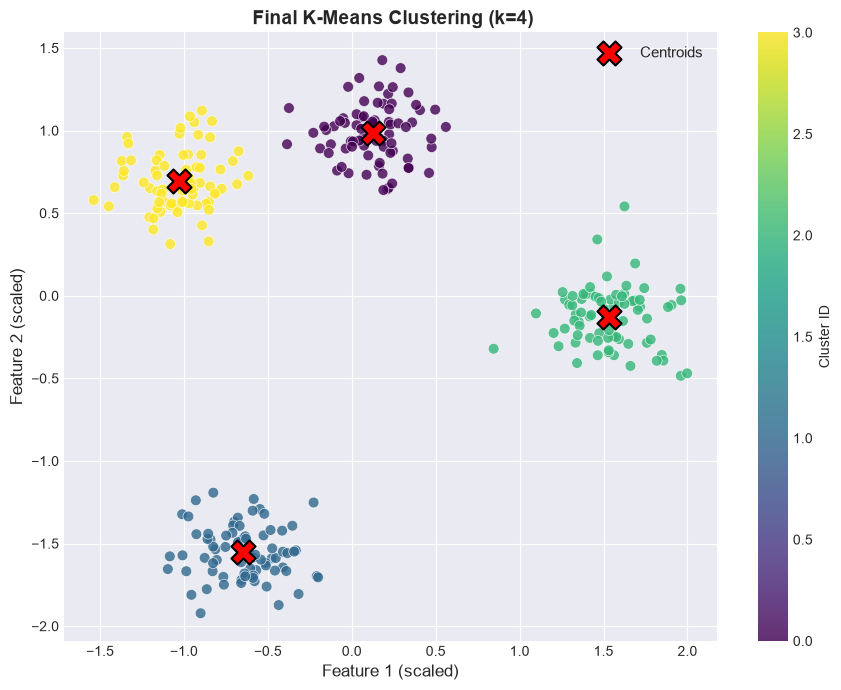

🎉 Done! Data successfully split into 4 clusters.


In [10]:
# 🔧 TODO: set the k value you chose
best_k = 4

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_labels = km_final.fit_predict(X_scaled)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
                       c=final_labels, cmap='viridis',
                       s=60, alpha=0.8, edgecolors='white', linewidth=0.5)
plt.scatter(km_final.cluster_centers_[:, 0], km_final.cluster_centers_[:, 1],
            c='red', marker='X', s=300, edgecolors='black',
            linewidth=1.5, label=' Centroids', zorder=5)

plt.xlabel('Feature 1 (scaled)', fontsize=12)
plt.ylabel('Feature 2 (scaled)', fontsize=12)
plt.title(f' Final K-Means Clustering (k={best_k})')
plt.legend(fontsize=11)
plt.colorbar(scatter, label='Cluster ID')
plt.tight_layout()
plt.show()

print(f'🎉 Done! Data successfully split into {best_k} clusters.')

### 📊 Cluster Centers Summary

| Cluster | feature_1 | feature_2 | Position |
|---|---|---|---|
| 0 | -2.72 | 8.97 | Upper-left region |
| 1 | -6.83 | -6.83 | Lower-left region |
| 2 | 4.73 | 2.05 | Right-center region |
| 3 | -8.88 | 7.16 | Far upper-left region |

- **Cluster 0:** Located in the upper-left area with a moderate feature_1 value (-2.72) and a high feature_2 value (8.97). This group is moderately spread and positioned above the center.
- **Cluster 1:** Sits in the lower-left region, with both feature_1 and feature_2 strongly negative (-6.83, -6.83). This is the most isolated cluster, clearly separated from the rest.
- **Cluster 2:** The only cluster with a positive feature_1 value (4.73), placing it on the right side of the feature space — distinctly separated from Clusters 0, 1, and 3.
- **Cluster 3:** Has the most negative feature_1 value (-8.88) combined with a high feature_2 value (7.16), making it the farthest-left cluster in the upper region.

**Think about it:** Since this is synthetic data generated with `make_blobs`, these 4 clusters simply confirm that K-Means correctly recovered the 4 underlying groups the data was designed to have — each cluster is clearly separated in the feature space with no overlap. On real-world data, `feature_1` and `feature_2` would represent actual measurable attributes (e.g., income and age), and this same table would reveal meaningful segments (e.g., "high-income, older customers" vs. "low-income, younger customers").

In [11]:
df['cluster'] = final_labels
df.groupby('cluster').mean()

,feature_1,feature_2
cluster,,
0,-2.721545,8.969373
1,-6.827625,-6.825492
2,4.726038,2.048659
3,-8.877097,7.159689


---
## ✅ Wrap-Up

| ✔️ You accomplished today |
|---|
| 📏 Scaled the data before clustering |
| ⚡ Found the ideal k using the Elbow Method |
| 🌟 Validated the choice with Silhouette Score |
| 🎨 Visualized and interpreted the final result |


🚀 **Up next:** DBSCAN & Hierarchical Clustering! 🔥

---
## 📋 Summary

<table>
  <tr>
    <th align="left">🔑 Key Metric</th>
    <th align="left">📊 Result</th>
  </tr>
  <tr>
    <td>Optimal number of clusters (k)</td>
    <td><b>4</b> — confirmed by both Elbow Method ⚡ and Silhouette Score 🌟</td>
  </tr>
  <tr>
    <td>Data preprocessing</td>
    <td>Scaled with <code>StandardScaler</code> before clustering 📏</td>
  </tr>
  <tr>
    <td>Cluster separation</td>
    <td>4 clearly separated, non-overlapping clusters — no noise points detected</td>
  </tr>
  <tr>
    <td>Most distinctive cluster</td>
    <td>Cluster 2 — the only group with a positive <code>feature_1</code> value</td>
  </tr>
</table>

### 🧠 What I Learned Today
1. Unsupervised learning finds structure in data **without** any labeled answers.
2. K-Means needs the right **k** — chosen with the Elbow Method and confirmed with Silhouette Score.
3. Scaling is **not optional** for distance-based algorithms like K-Means.
4. A cluster's numbers only become meaningful once you **interpret** them in context.

### 💡 Key Takeaway
> K-Means successfully partitioned the dataset into 4 well-separated groups, validated both visually and statistically. This confirms the algorithm correctly recovered the underlying structure — and the same workflow (scale → elbow → silhouette → interpret) is exactly what tomorrow's methods (DBSCAN, Hierarchical) will be compared against.

---
🚀 **Status:** Day 1 Complete ✅ | **Next:** DBSCAN & Hierarchical Clustering 🔥